In [1]:
# librerias 

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

In [2]:
# cargar data 
BASE_DIR = Path().resolve().parent

# datasets por año
data2009 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2009.csv", low_memory=False)
data2010 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2010.csv", low_memory=False)
data2011 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2011.csv", low_memory=False)
data2012 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2012.csv", low_memory=False)
data2013 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2013.csv", low_memory=False)
data2014 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2014.csv", low_memory=False)
data2015 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2015.csv", low_memory=False)
data2016 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2016.csv", low_memory=False)
data2017 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2017.csv", low_memory=False)
data2018 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2018.csv", low_memory=False)
data2019 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2019.csv", low_memory=False)
data2020 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2020.csv", low_memory=False)
data2021 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2021.csv", low_memory=False)
data2022 = pd.read_csv(BASE_DIR / "data/processed/defunciones_2022.csv", low_memory=False)

# diccionarios
diccionario_defun = pd.read_csv(BASE_DIR / "data/processed/diccionario_defunciones.csv", encoding="latin1", sep=";" )
diccionario_cie = pd.read_csv(BASE_DIR / "data/processed/diccionario_codigos_CIE-10.csv",   encoding="latin1", sep=";",)
diccionario_cie_cat = pd.read_csv(BASE_DIR / "data/processed/diccionario_categorías_subcategorías_CIE-10.csv",   encoding="latin1", sep=";")


#
dataE2017 = pd.read_csv(BASE_DIR / "data/raw/Transform/evaluaciones_2017.csv", low_memory=False)


### Diccionarios

In [3]:
diccionario_defun.head(5)

,Variable,Código,Etiqueta
0,Depreg,1,Guatemala
1,Depreg,2,El Progreso
2,Depreg,3,Sacatepéquez
3,Depreg,4,Chimaltenango
4,Depreg,5,Escuintla


In [4]:
# cuántos tipos de variables hay en el de defunción
diccionario_defun["Código"].nunique()

889

In [5]:
diccionario_cie.head(2)


,Causa de defuncion,Codigos CIE-10,Codigos CIE-10.1
0,Asist,1,Médica
1,Asist,2,Paramédica


In [6]:
diccionario_cie["Codigos CIE-10"].nunique()

9

In [7]:
diccionario_cie_cat.head(2)


,CAUSA,DESCRIP
0,A00,Cólera
1,A000,"Cólera debido a Vibrio cholerae 01, biotipo ch..."


In [8]:
diccionario_cie_cat["CAUSA"].nunique()

14238

### Data

In [9]:
# los registros totales de la data
data_all = pd.concat([ data2009.assign(anio=2009), data2010.assign(anio=2010), data2011.assign(anio=2011), data2012.assign(anio=2012), data2013.assign(anio=2013), data2014.assign(anio=2014), data2015.assign(anio=2015), data2016.assign(anio=2016), data2017.assign(anio=2017), data2018.assign(anio=2018), data2019.assign(anio=2019), data2020.assign(anio=2020), data2021.assign(anio=2021), data2022.assign(anio=2022), ], ignore_index=True)
data_all.shape

(1167602, 36)

In [10]:
# variables de la data
list(data_all.columns)


['Depreg',
 'Mupreg',
 'Mesreg',
 'Añoreg',
 'Depocu',
 'Mupocu',
 'Areag',
 'Sexo',
 'Diaocu',
 'Mesocu',
 'Añoocu',
 'Edadif',
 'Perdif',
 'Getdif',
 'Ecidif',
 'Ocudif',
 'Dnadif',
 'Mnadif',
 'Nacdif',
 'Dredif',
 'Mredif',
 'Caudef',
 'Asist',
 'Ocur',
 'Cerdef',
 'anio',
 'mupreg',
 'mupocu',
 'añoocu',
 'Escodif',
 'mnadif',
 'Pnadif',
 'Predif',
 'Puedif',
 'Ciuodif',
 'caudef.descrip']

In [11]:
print(data_all.columns)

Index(['Depreg', 'Mupreg', 'Mesreg', 'Añoreg', 'Depocu', 'Mupocu', 'Areag',
       'Sexo', 'Diaocu', 'Mesocu', 'Añoocu', 'Edadif', 'Perdif', 'Getdif',
       'Ecidif', 'Ocudif', 'Dnadif', 'Mnadif', 'Nacdif', 'Dredif', 'Mredif',
       'Caudef', 'Asist', 'Ocur', 'Cerdef', 'anio', 'mupreg', 'mupocu',
       'añoocu', 'Escodif', 'mnadif', 'Pnadif', 'Predif', 'Puedif', 'Ciuodif',
       'caudef.descrip'],
      dtype='str')


In [12]:
# los registros que hay por año
data_all["anio"].value_counts().sort_index()


anio
2009     71707
2010     72748
2011     72354
2012     72657
2013     76639
2014     77807
2015     80876
2016     82565
2017     81726
2018     83071
2019     85600
2020     96001
2021    118465
2022     95386
Name: count, dtype: int64

##### Resumen de la data 

In [13]:

data_all.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Depreg,1167602.0,NaN,NaN,NaN,8.632042,6.690105,1.0,1.0,9.0,14.0,22.0
Mupreg,1022500.0,NaN,NaN,NaN,869.559309,669.798178,101.0,103.0,901.0,1406.0,2217.0
Mesreg,1167602.0,NaN,NaN,NaN,6.503207,3.430613,1.0,4.0,7.0,9.0,12.0
Añoreg,1167602.0,NaN,NaN,NaN,1893.195257,481.982417,9.0,2013.0,2016.0,2020.0,2023.0
Depocu,1167602.0,NaN,NaN,NaN,8.602418,6.66619,1.0,1.0,9.0,14.0,22.0
Mupocu,1022500.0,NaN,NaN,NaN,866.889631,666.767946,101.0,113.0,901.0,1406.0,2217.0
Areag,689079.0,NaN,NaN,NaN,1.596917,1.160354,1.0,1.0,1.0,2.0,9.0
Sexo,1167602.0,NaN,NaN,NaN,1.436969,0.496011,1.0,1.0,1.0,2.0,2.0
Diaocu,1167602.0,NaN,NaN,NaN,15.672263,8.814839,1.0,8.0,16.0,23.0,31.0
Mesocu,1167602.0,NaN,NaN,NaN,6.561291,3.424092,1.0,4.0,7.0,9.0,12.0


In [14]:
data_all.describe()

,Depreg,Mupreg,Mesreg,Añoreg,Depocu,Mupocu,Areag,Sexo,Diaocu,Mesocu,...,Cerdef,anio,mupreg,mupocu,añoocu,Escodif,mnadif,Pnadif,Predif,Puedif
count,1.167602e+06,1.022500e+06,1.167602e+06,1.167602e+06,1.167602e+06,1.022500e+06,689079.000000,1.167602e+06,1.167602e+06,1.167602e+06,...,1.167602e+06,1.167602e+06,145102.000000,145102.000000,145102.000000,1.095895e+06,72748.000000,950793.000000,950793.000000,878136.000000
mean,8.632042e+00,8.695593e+02,6.503207e+00,1.893195e+03,8.602418e+00,8.668896e+02,1.596917,1.436969e+00,1.567226e+01,6.561291e+00,...,3.983861e+00,2.015997e+03,866.225476,863.574713,2010.498642,2.291988e+00,1125.603797,376.925210,1080.544882,4.078857
std,6.690105e+00,6.697982e+02,3.430613e+00,4.819824e+02,6.666190e+00,6.667679e+02,1.160354,4.960114e-01,8.814839e+00,3.424092e+00,...,3.845096e+00,4.065845e+00,675.762877,673.383045,0.500000,2.254365e+00,1127.835615,735.770567,2603.734900,2.654025
min,1.000000e+00,1.010000e+02,1.000000e+00,9.000000e+00,1.000000e+00,1.010000e+02,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,2.009000e+03,101.000000,101.000000,2010.000000,1.000000e+00,101.000000,10.000000,40.000000,1.000000
25%,1.000000e+00,1.030000e+02,4.000000e+00,2.013000e+03,1.000000e+00,1.130000e+02,1.000000,1.000000e+00,8.000000e+00,4.000000e+00,...,1.000000e+00,2.013000e+03,108.000000,108.000000,2010.000000,1.000000e+00,411.000000,320.000000,320.000000,1.000000
50%,9.000000e+00,9.010000e+02,7.000000e+00,2.016000e+03,9.000000e+00,9.010000e+02,1.000000,1.000000e+00,1.600000e+01,7.000000e+00,...,1.000000e+00,2.016000e+03,901.000000,901.000000,2010.000000,1.000000e+00,1017.000000,320.000000,320.000000,4.000000
75%,1.400000e+01,1.406000e+03,9.000000e+00,2.020000e+03,1.400000e+01,1.406000e+03,2.000000,2.000000e+00,2.300000e+01,9.000000e+00,...,9.000000e+00,2.020000e+03,1406.000000,1406.000000,2011.000000,2.000000e+00,1601.000000,320.000000,320.000000,4.000000
max,2.200000e+01,2.217000e+03,1.200000e+01,2.023000e+03,2.200000e+01,2.217000e+03,9.000000,2.000000e+00,3.100000e+01,1.200000e+01,...,9.000000e+00,2.022000e+03,2217.000000,2217.000000,2011.000000,9.000000e+00,9999.000000,9999.000000,9999.000000,9.000000


##### Defunciones por año

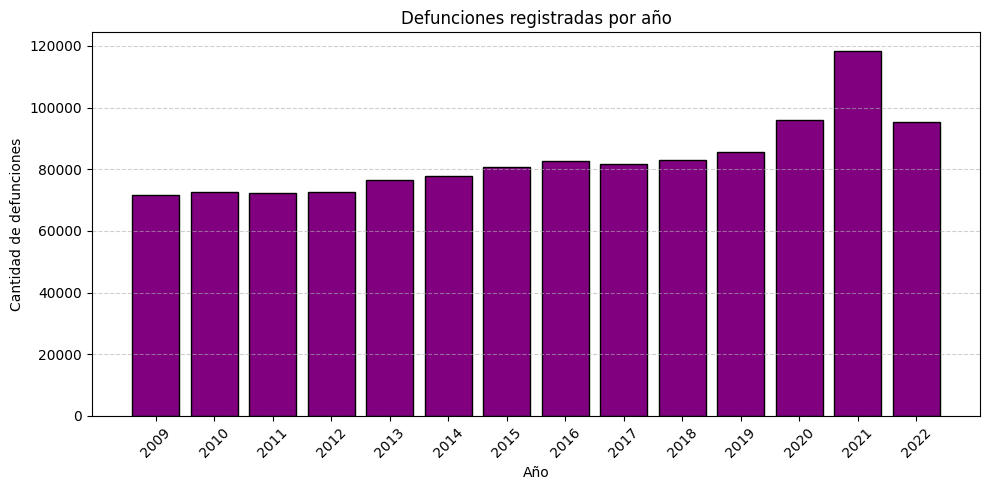

In [15]:
conteo_anual = data_all["anio"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(
    conteo_anual.index.astype(str), 
    conteo_anual.values,
    color="purple",
    edgecolor="black"
)
plt.xlabel("Año")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones registradas por año")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

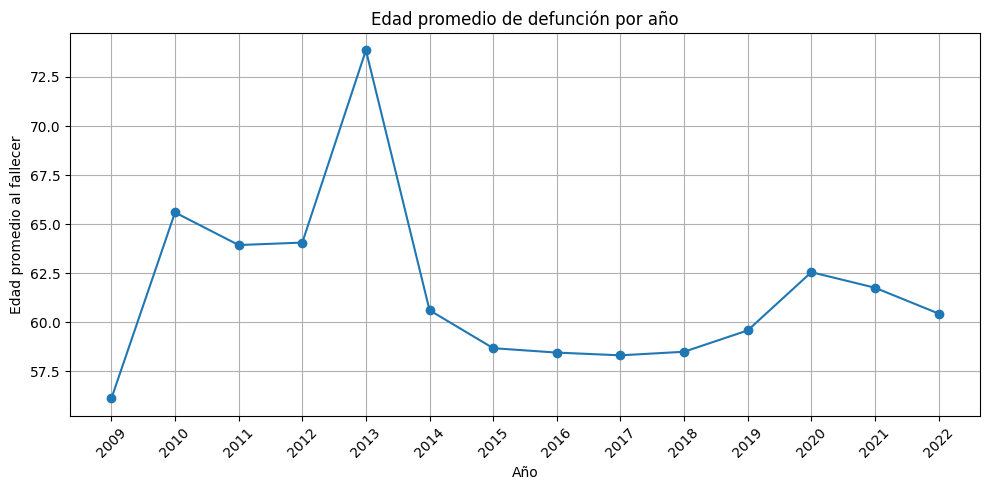

In [16]:
# Edad promedio de defunción por año

edad_promedio_anio = data_all.groupby("anio")["Edadif"].mean()

plt.figure(figsize=(10,5))
plt.plot(
    edad_promedio_anio.index.astype(str), 
    edad_promedio_anio.values,
    marker="o"
)
plt.xlabel("Año")
plt.ylabel("Edad promedio al fallecer")
plt.title("Edad promedio de defunción por año")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

##### defuncion por edad

In [17]:
edad_limpia = data_all.loc[
    (data_all["Edadif"].notna()) & 
    (data_all["Edadif"] >= 0) & 
    (data_all["Edadif"] < 120),
    "Edadif"
]
edad_limpia.describe()


count    1.158909e+06
mean     5.449856e+01
std      2.786492e+01
min      0.000000e+00
25%      3.300000e+01
50%      6.100000e+01
75%      7.800000e+01
max      1.180000e+02
Name: Edadif, dtype: float64

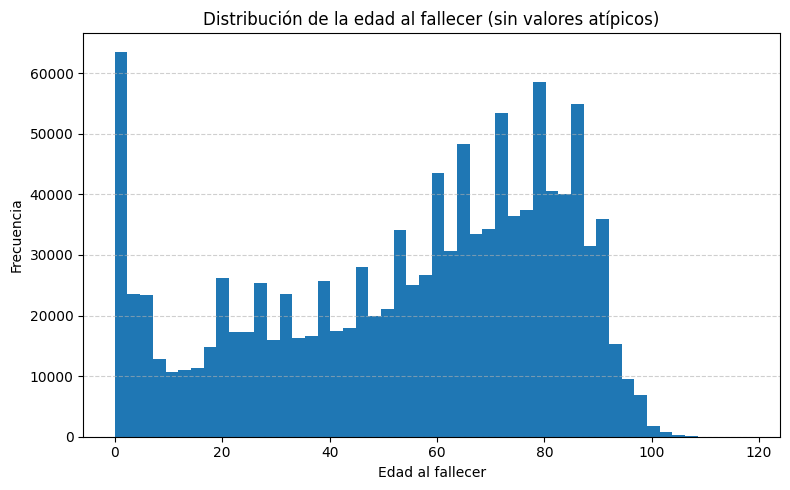

In [18]:
plt.figure(figsize=(8,5))
plt.hist(edad_limpia, bins=50)
plt.xlabel("Edad al fallecer")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad al fallecer (sin valores atípicos)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


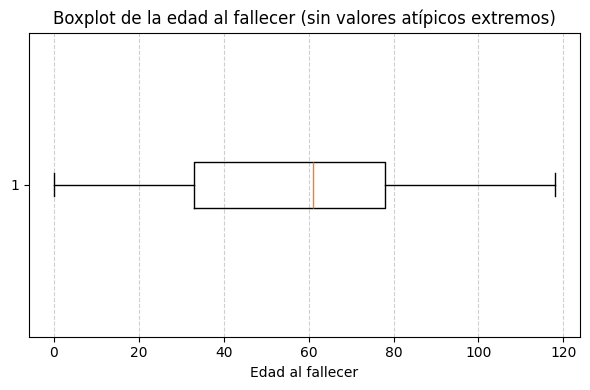

In [19]:
plt.figure(figsize=(6,4))
plt.boxplot(edad_limpia, vert=False)
plt.xlabel("Edad al fallecer")
plt.title("Boxplot de la edad al fallecer (sin valores atípicos extremos)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



##### Defuncion por Genero

In [20]:
mapa_sexo = {
    1: "Hombre",
    2: "Mujer"
}
data_all["Sexo_desc"] = data_all["Sexo"].map(mapa_sexo)


In [21]:
data_all["Sexo_desc"].value_counts()


Sexo_desc
Hombre    657396
Mujer     510206
Name: count, dtype: int64

In [22]:
data_all["Sexo_desc"].value_counts(normalize=True) * 100


Sexo_desc
Hombre    56.30309
Mujer     43.69691
Name: proportion, dtype: float64

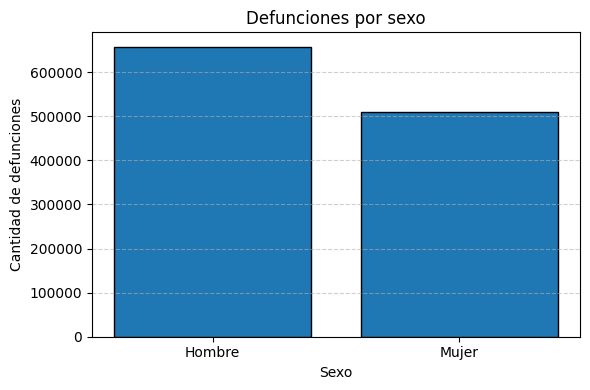

In [23]:
conteo_sexo = data_all["Sexo_desc"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    conteo_sexo.index.astype(str),
    conteo_sexo.values,
    edgecolor="black"
)
plt.xlabel("Sexo")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones por sexo")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


##### Defunciones por area 


In [24]:
mapa_area = {
    1: "Urbana",
    2: "Rural"
}

data_all["Area_desc"] = data_all["Areag"].map(mapa_area)


In [25]:
data_all["Area_desc"].value_counts()


Area_desc
Urbana    373005
Rural     302467
Name: count, dtype: int64

In [26]:
data_all["Area_desc"].value_counts(normalize=True) * 100


Area_desc
Urbana    55.221386
Rural     44.778614
Name: proportion, dtype: float64

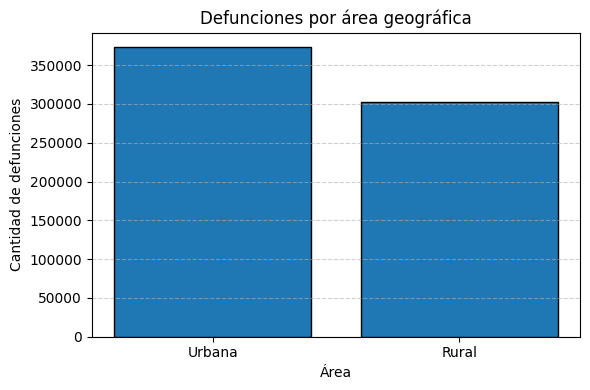

In [27]:
conteo_area = data_all["Area_desc"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    conteo_area.index,
    conteo_area.values,
    edgecolor="black"
)
plt.xlabel("Área")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones por área geográfica")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


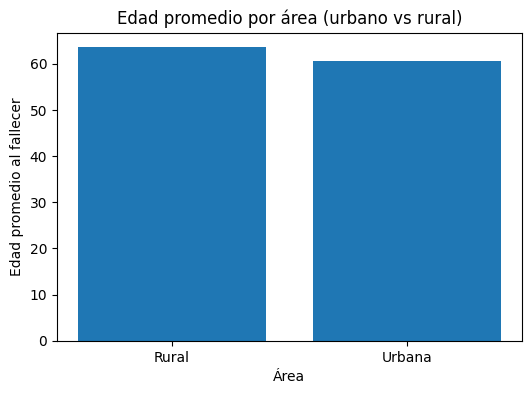

In [28]:
# Edad promedio de defunción por área (urbano vs rural)
edad_promedio_area = data_all.groupby("Area_desc")["Edadif"].mean()

plt.figure(figsize=(6,4))
plt.bar(edad_promedio_area.index, edad_promedio_area.values)
plt.xlabel("Área")
plt.ylabel("Edad promedio al fallecer")
plt.title("Edad promedio por área (urbano vs rural)")
plt.show()

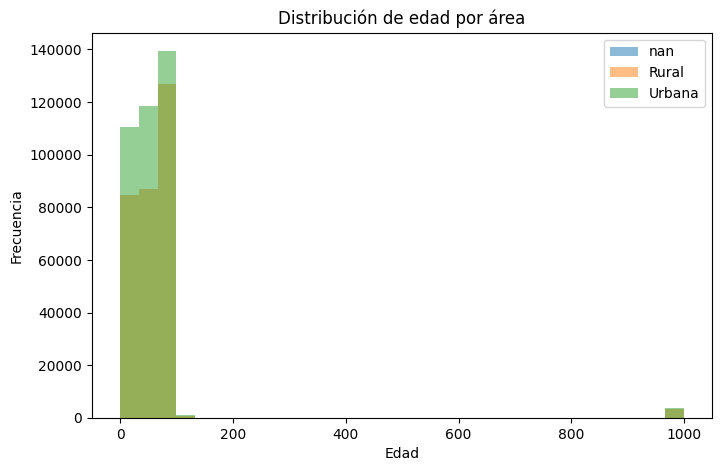

In [29]:
# Distribución de edad por área
plt.figure(figsize=(8,5))

for area in data_all["Area_desc"].unique():
    subset = data_all[data_all["Area_desc"] == area]
    plt.hist(subset["Edadif"], bins=30, alpha=0.5, label=area)

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad por área")
plt.legend()
plt.show()

##### Defunciones por departamento

In [30]:
diccionario_dep = diccionario_defun[diccionario_defun["Variable"] == "Depreg"]

mapa_dep = dict(
    zip(diccionario_dep["Código"], diccionario_dep["Etiqueta"])
)

data_all["Departamento"] = data_all["Depreg"].map(mapa_dep)


In [31]:
data_all["Departamento"].value_counts().head(10)


Departamento
Guatemala         344116
Quetzaltenango     72051
Alta Verapaz       70046
San Marcos         69249
Huehuetenango      65760
Escuintla          65394
Quiché             58087
Suchitepéquez      43823
Chimaltenango      41080
Jutiapa            35478
Name: count, dtype: int64

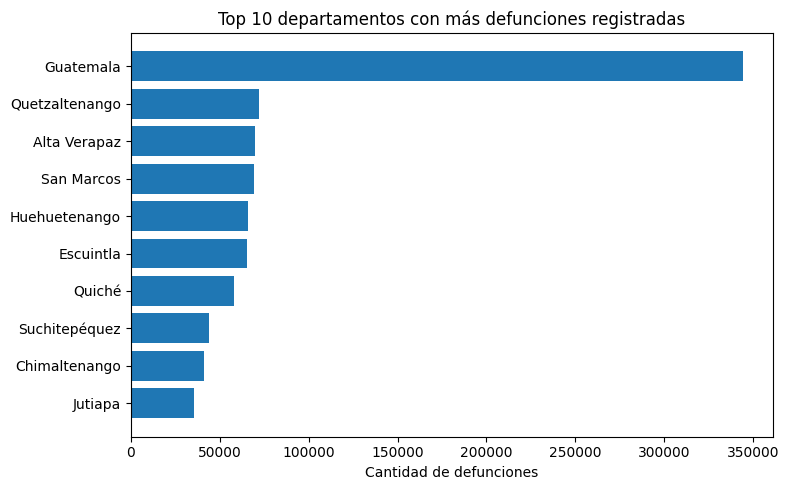

In [32]:
top_dep = data_all["Departamento"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(top_dep.index, top_dep.values)
plt.xlabel("Cantidad de defunciones")
plt.title("Top 10 departamentos con más defunciones registradas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


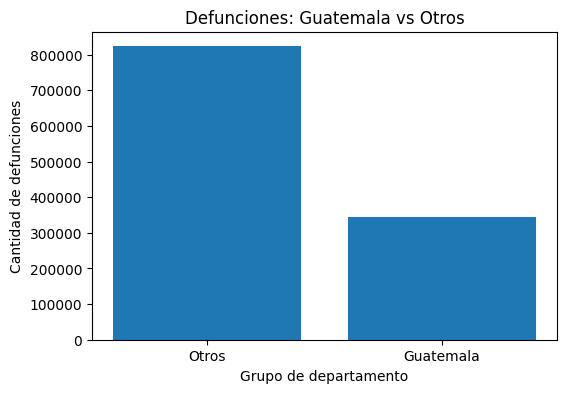

In [33]:
# Separación: Guatemala vs resto de departamentos
# Crear nueva variable de grupo
data_all["grupo_dep"] = data_all["Departamento"].apply(
    lambda x: "Guatemala" if x == "Guatemala" else "Otros"
)

# Conteo por grupo
conteo_grupo = data_all["grupo_dep"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(conteo_grupo.index, conteo_grupo.values)
plt.xlabel("Grupo de departamento")
plt.ylabel("Cantidad de defunciones")
plt.title("Defunciones: Guatemala vs Otros")
plt.show()

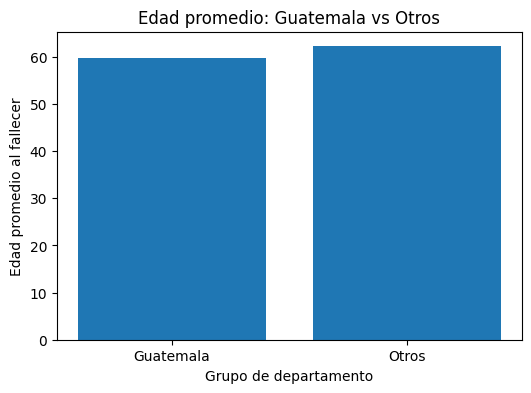

In [34]:
# Edad promedio: Guatemala vs resto
edad_promedio_grupo = data_all.groupby("grupo_dep")["Edadif"].mean()

plt.figure(figsize=(6,4))
plt.bar(edad_promedio_grupo.index, edad_promedio_grupo.values)
plt.xlabel("Grupo de departamento")
plt.ylabel("Edad promedio al fallecer")
plt.title("Edad promedio: Guatemala vs Otros")
plt.show()

##### Defuncion por causa

In [35]:
data_all["caudef.descrip"].value_counts().head(10)


caudef.descrip
Neumonía, no especificada                                                                      5251
Infarto agudo del miocardio, sin otra especificación                                           4809
Exposición a factores no especificados, causando otras lesiones y las no especificadas         2703
Diabetes mellitus no especificada, sin mención de complicación                                 2582
Diarrea y gastroenteritis de presunto origen infeccioso                                        2282
Bronconeumonía, no especificada                                                                1984
Muerte sin asistencia                                                                          1906
Otras cirrosis del hígado y las no especificadas                                               1886
Accidente vascular encefálico agudo, no especificado como hemorrágico o isquémico              1836
Agresión con disparo de otras armas de fuego, y las no especificadas, lugar no especi

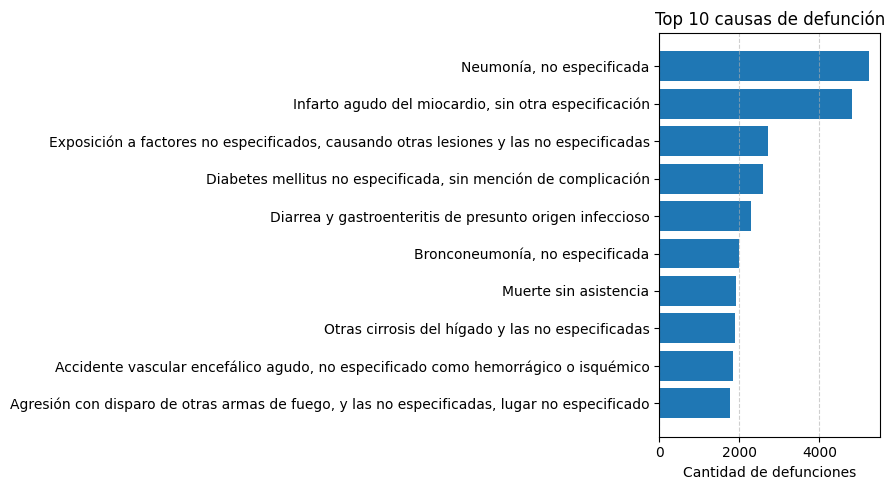

In [36]:
top_causas = data_all["caudef.descrip"].value_counts().head(10)

plt.figure(figsize=(9,5))
plt.barh(top_causas.index, top_causas.values)
plt.xlabel("Cantidad de defunciones")
plt.title("Top 10 causas de defunción")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [37]:
# Creación de variable: tipo de causa
def clasificar_causa(causa):
    causa = str(causa).lower()
    
    if "neumon" in causa or "infe" in causa or "resp" in causa:
        return "Infecciosas"
    
    elif "infarto" in causa or "cardio" in causa or "hipert" in causa:
        return "Cardiovasculares"
    
    elif "diabet" in causa or "cancer" in causa or "tumor" in causa:
        return "Cronicas"
    
    elif "accidente" in causa or "homicidio" in causa or "violencia" in causa:
        return "Externas"
    
    else:
        return "Otras"


data_all["tipo_causa"] = data_all["caudef.descrip"].apply(clasificar_causa)

In [38]:
# Conteo por tipo de causa
data_all["tipo_causa"].value_counts()

tipo_causa
Otras               1133501
Cronicas              12482
Infecciosas           12420
Cardiovasculares       6176
Externas               3023
Name: count, dtype: int64

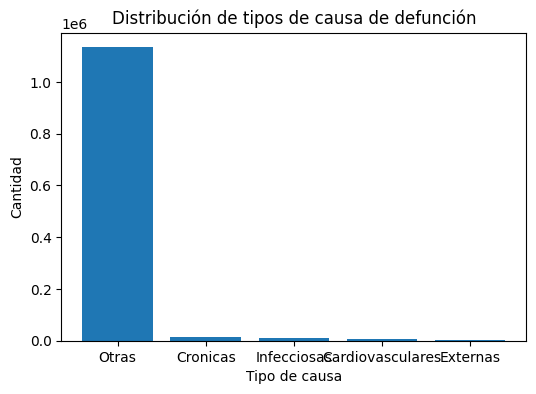

In [39]:
# Distribución de tipos de causa
conteo_tipo = data_all["tipo_causa"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(conteo_tipo.index, conteo_tipo.values)
plt.xlabel("Tipo de causa")
plt.ylabel("Cantidad")
plt.title("Distribución de tipos de causa de defunción")
plt.show()

#### Datos cruzados 

In [40]:
#edad + sexo
data_cruce = data_all[
    (data_all["Edadif"] >= 0) & (data_all["Edadif"] < 120)
]


<Figure size 600x400 with 0 Axes>

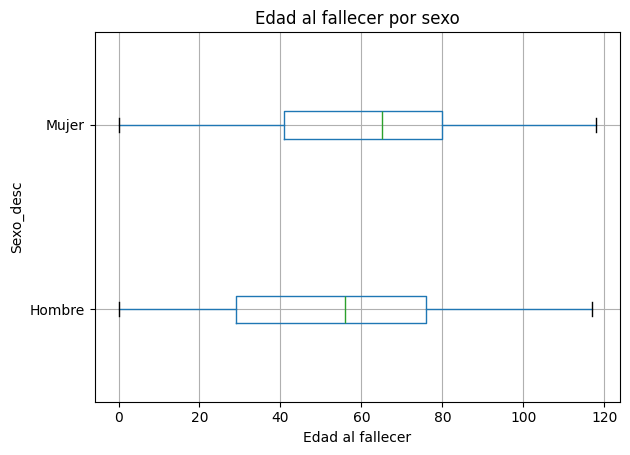

In [41]:
plt.figure(figsize=(6,4))
data_cruce.boxplot(
    column="Edadif",
    by="Sexo_desc",
    vert=False
)
plt.xlabel("Edad al fallecer")
plt.title("Edad al fallecer por sexo")
plt.suptitle("")
plt.tight_layout()
plt.show()


In [42]:
#causa x sexo
top_causas = data_all["caudef.descrip"].value_counts().head(5).index

tabla_causa_sexo = pd.crosstab(
    data_all["Sexo_desc"],
    data_all["caudef.descrip"]
)[top_causas]

tabla_causa_sexo


caudef.descrip,"Neumonía, no especificada","Infarto agudo del miocardio, sin otra especificación","Exposición a factores no especificados, causando otras lesiones y las no especificadas","Diabetes mellitus no especificada, sin mención de complicación",Diarrea y gastroenteritis de presunto origen infeccioso
Sexo_desc,,,,,
Hombre,2750,2579,2210,1044,1206
Mujer,2501,2230,493,1538,1076


C:\Users\agabr\AppData\Local\Temp\ipykernel_5924\2405306157.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


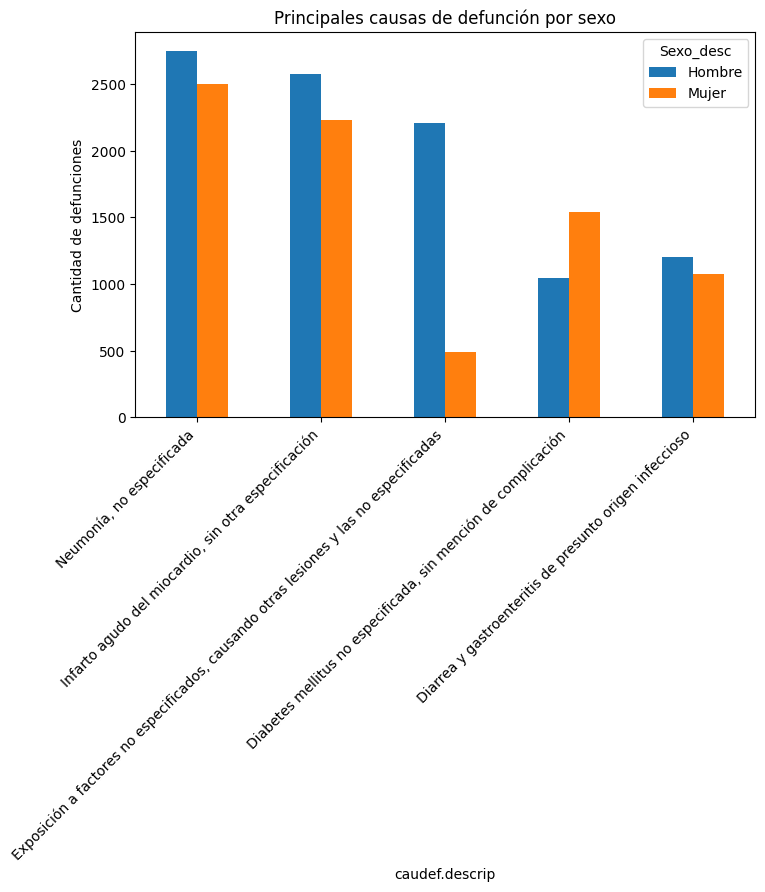

In [43]:
tabla_causa_sexo.T.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Cantidad de defunciones")
plt.title("Principales causas de defunción por sexo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [44]:
#area X causa
tabla_area_causa = pd.crosstab(
    data_all["Area_desc"],
    data_all["caudef.descrip"]
)[top_causas]

tabla_area_causa


caudef.descrip,"Neumonía, no especificada","Infarto agudo del miocardio, sin otra especificación","Exposición a factores no especificados, causando otras lesiones y las no especificadas","Diabetes mellitus no especificada, sin mención de complicación",Diarrea y gastroenteritis de presunto origen infeccioso
Area_desc,,,,,
Rural,3737,2468,741,974,1873
Urbana,1420,2215,1890,1563,374


C:\Users\agabr\AppData\Local\Temp\ipykernel_5924\4173242440.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


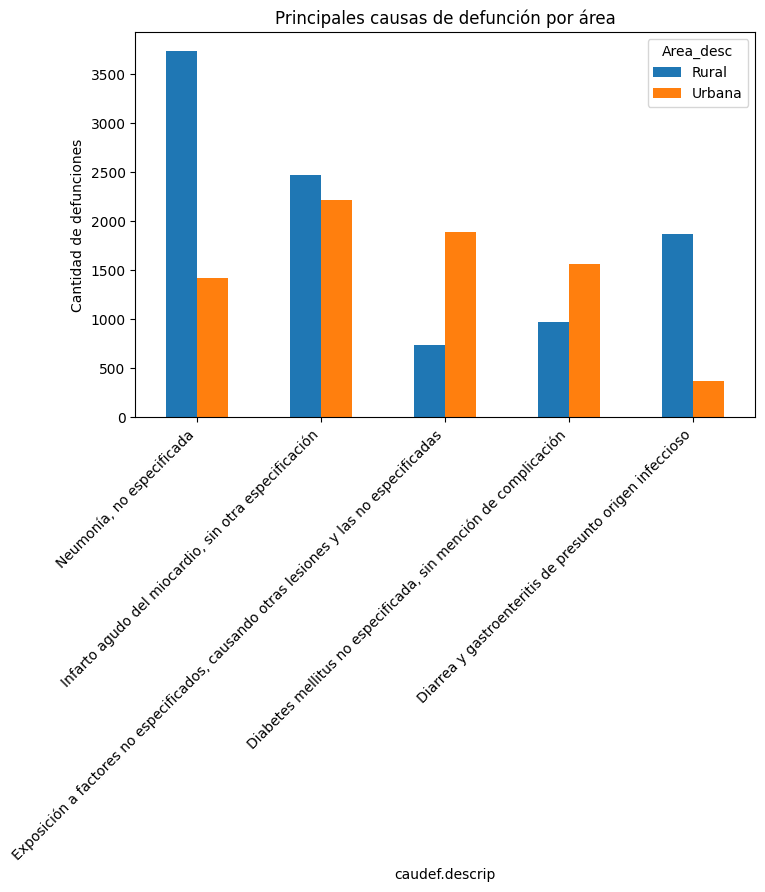

In [45]:
tabla_area_causa.T.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Cantidad de defunciones")
plt.title("Principales causas de defunción por área")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [46]:
#departamento x area 
top_deps = data_all["Departamento"].value_counts().head(5).index


In [47]:
tabla_dep_anio = pd.crosstab(
    data_all["anio"],
    data_all["Departamento"]
)[top_deps]

tabla_dep_anio.head()


Departamento,Guatemala,Quetzaltenango,Alta Verapaz,San Marcos,Huehuetenango
anio,,,,,
2009,21391,4465,4355,4351,3908
2010,22409,4272,4580,4172,4140
2011,21629,4475,4219,4412,4183
2012,21068,4301,4354,4490,4030
2013,22141,4494,4719,4551,4295


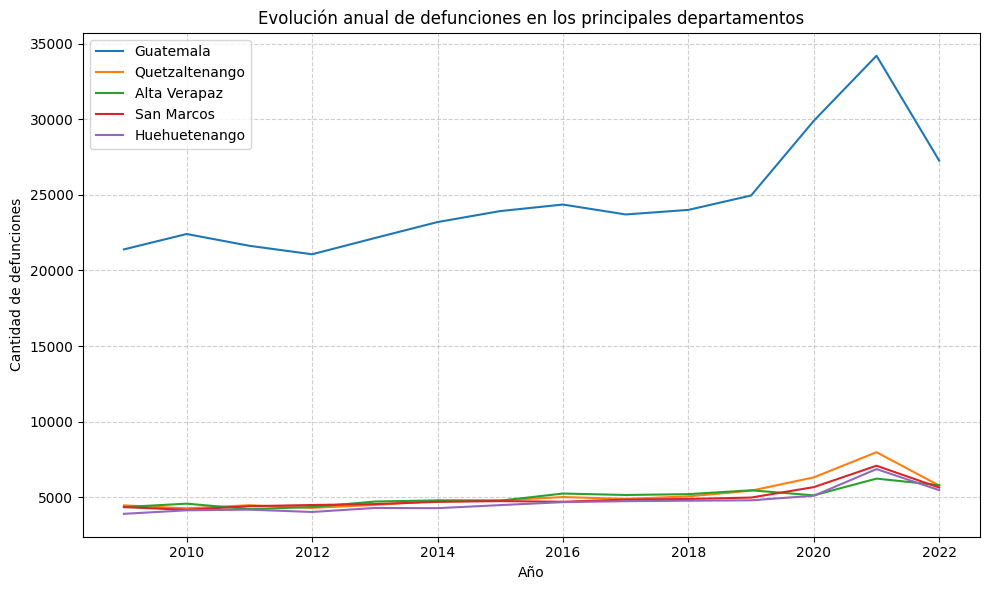

In [48]:
plt.figure(figsize=(10,6))

for dep in top_deps:
    plt.plot(
        tabla_dep_anio.index,
        tabla_dep_anio[dep],
        label=dep
    )

plt.xlabel("Año")
plt.ylabel("Cantidad de defunciones")
plt.title("Evolución anual de defunciones en los principales departamentos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [49]:
# Cruce: tipo de causa vs área
tabla_causa_area = pd.crosstab(data_all["tipo_causa"], data_all["Area_desc"])

tabla_causa_area

Area_desc,Rural,Urbana
tipo_causa,,
Cardiovasculares,2923,3090
Cronicas,4949,7264
Externas,1650,1219
Infecciosas,7871,4328
Otras,285074,357104


In [50]:
# Proporción de tipo de causa por área
tabla_prop = pd.crosstab(
    data_all["tipo_causa"], 
    data_all["Area_desc"], 
    normalize="columns"
)

tabla_prop

Area_desc,Rural,Urbana
tipo_causa,,
Cardiovasculares,0.009664,0.008284
Cronicas,0.016362,0.019474
Externas,0.005455,0.003268
Infecciosas,0.026023,0.011603
Otras,0.942496,0.957371


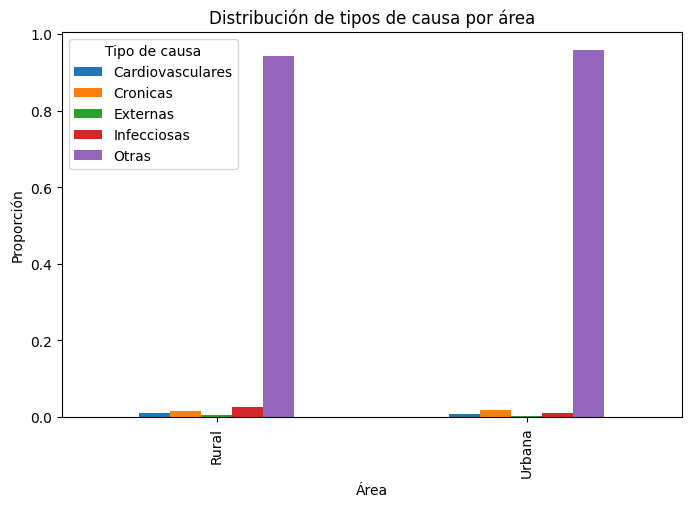

In [51]:
# Gráfico: proporción de tipos de causa por área
tabla_prop.T.plot(kind="bar", figsize=(8,5))

plt.xlabel("Área")
plt.ylabel("Proporción")
plt.title("Distribución de tipos de causa por área")
plt.legend(title="Tipo de causa")
plt.show()

In [52]:
# Cruce: tipo de causa vs sexo
tabla_causa_sexo = pd.crosstab(
    data_all["tipo_causa"], 
    data_all["Sexo_desc"]
)

tabla_causa_sexo

Sexo_desc,Hombre,Mujer
tipo_causa,,
Cardiovasculares,3184,2992
Cronicas,5316,7166
Externas,1828,1195
Infecciosas,6748,5672
Otras,640320,493181


In [53]:
# Proporción de tipo de causa por sexo
tabla_prop_sexo = pd.crosstab(
    data_all["tipo_causa"], 
    data_all["Sexo_desc"], 
    normalize="columns"
)

tabla_prop_sexo

Sexo_desc,Hombre,Mujer
tipo_causa,,
Cardiovasculares,0.004843,0.005864
Cronicas,0.008086,0.014045
Externas,0.002781,0.002342
Infecciosas,0.010265,0.011117
Otras,0.974025,0.966631


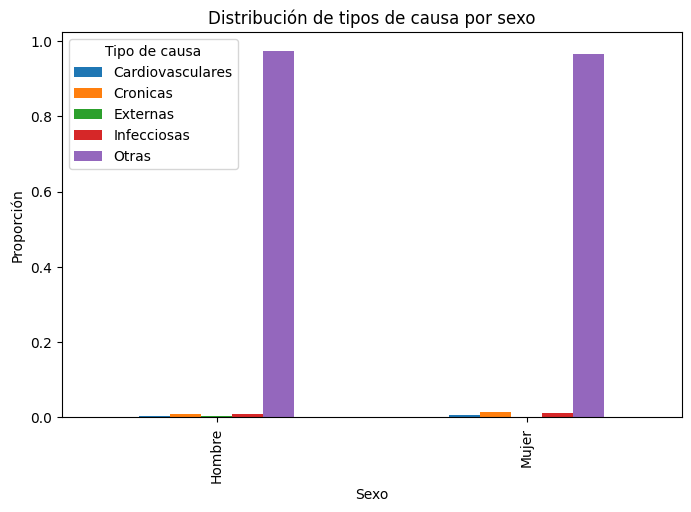

In [54]:
# Gráfico: tipo de causa por sexo
tabla_prop_sexo.T.plot(kind="bar", figsize=(8,5))

plt.xlabel("Sexo")
plt.ylabel("Proporción")
plt.title("Distribución de tipos de causa por sexo")
plt.legend(title="Tipo de causa")
plt.show()

### Clustering

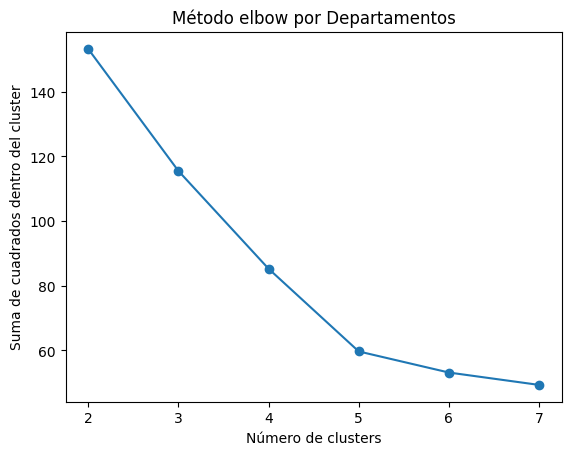

In [55]:
datos_para_clustering = data_all[
    ( data_all["Edadif"] >= 0 ) & ( data_all["Edadif"] <= 110 ) ].copy()

resumen_por_departamento = datos_para_clustering.groupby("Departamento").agg(
   
    edad_promedio= ("Edadif", "mean"),
    total_defunciones= ( "Edadif", "count" ) ,
    porcentaje_rural= ( "Area_desc", lambda x: (x == "Rural").mean() ),
    porcentaje_hombres= ( "Sexo_desc", lambda x:  (x == "Hombre").mean())
)

causas_tops = datos_para_clustering[ "caudef.descrip" ].value_counts().head(5).index

perfil_causas_depa= (
    datos_para_clustering[datos_para_clustering[ "caudef.descrip" ].isin(causas_tops)]
    .groupby([ "Departamento" , "caudef.descrip"])
    .size()
    .unstack(fill_value= 0)
)

causas_depa = perfil_causas_depa.div(perfil_causas_depa.sum(axis=1) , axis=0 )

datos_para_clustering = resumen_por_departamento.join(causas_depa).fillna(0)



datosEscalados = StandardScaler()
datosEscalados = datosEscalados.fit_transform( datos_para_clustering)

sumaDeCuadrados = []

for k in range(2,8):
    kmeans = KMeans(n_clusters=k , random_state =123)
    kmeans.fit(datosEscalados)
    sumaDeCuadrados.append( kmeans.inertia_)

plt.plot(range(2,8), sumaDeCuadrados, marker= "o" )
plt.title("Método elbow por Departamentos")
plt.xlabel("Número de clusters")
plt.ylabel("Suma de cuadrados dentro del cluster")
plt.show()


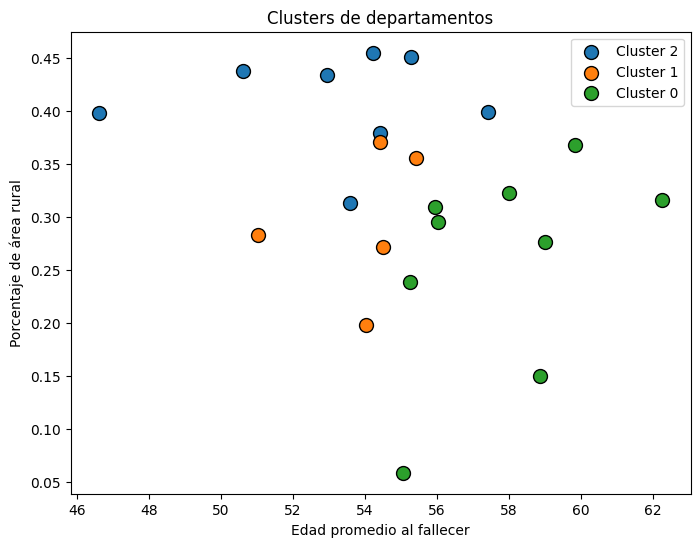

In [56]:
kmeans = KMeans(n_clusters=3, random_state=123)
datos_para_clustering["cluster"] = kmeans.fit_predict(datosEscalados)

datos_para_clustering["cluster"] = kmeans.fit_predict(datosEscalados)

plt.figure(figsize=(8,6))

for c in datos_para_clustering["cluster"].unique():
    subset = datos_para_clustering[datos_para_clustering["cluster"] == c]
    plt.scatter(
        subset["edad_promedio"],
        subset["porcentaje_rural"],
        label=f"Cluster {c}",
        s=100,
        edgecolor="black"
    )

plt.xlabel("Edad promedio al fallecer")
plt.ylabel("Porcentaje de área rural")
plt.legend()
plt.title("Clusters de departamentos")
plt.show()


### edad y porcentaje rural 

Para k = 2, silhouette = 0.308


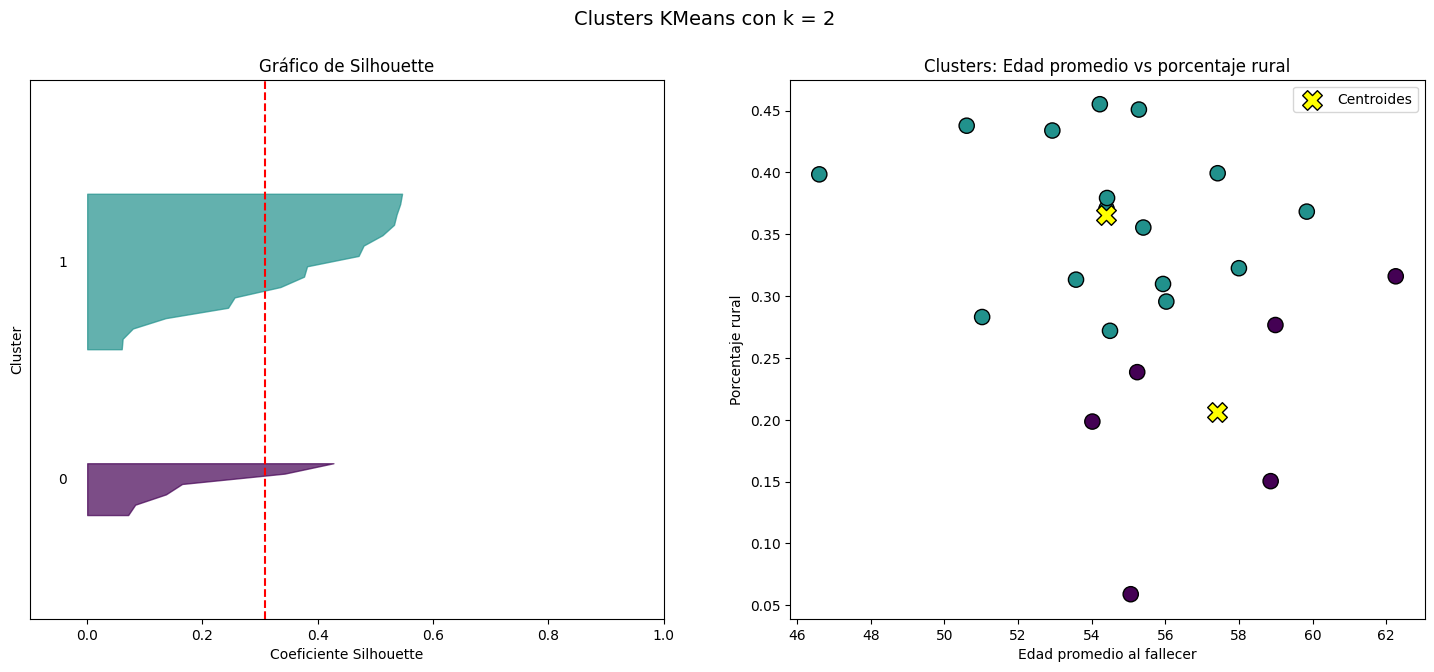

Para k = 3, silhouette = 0.309


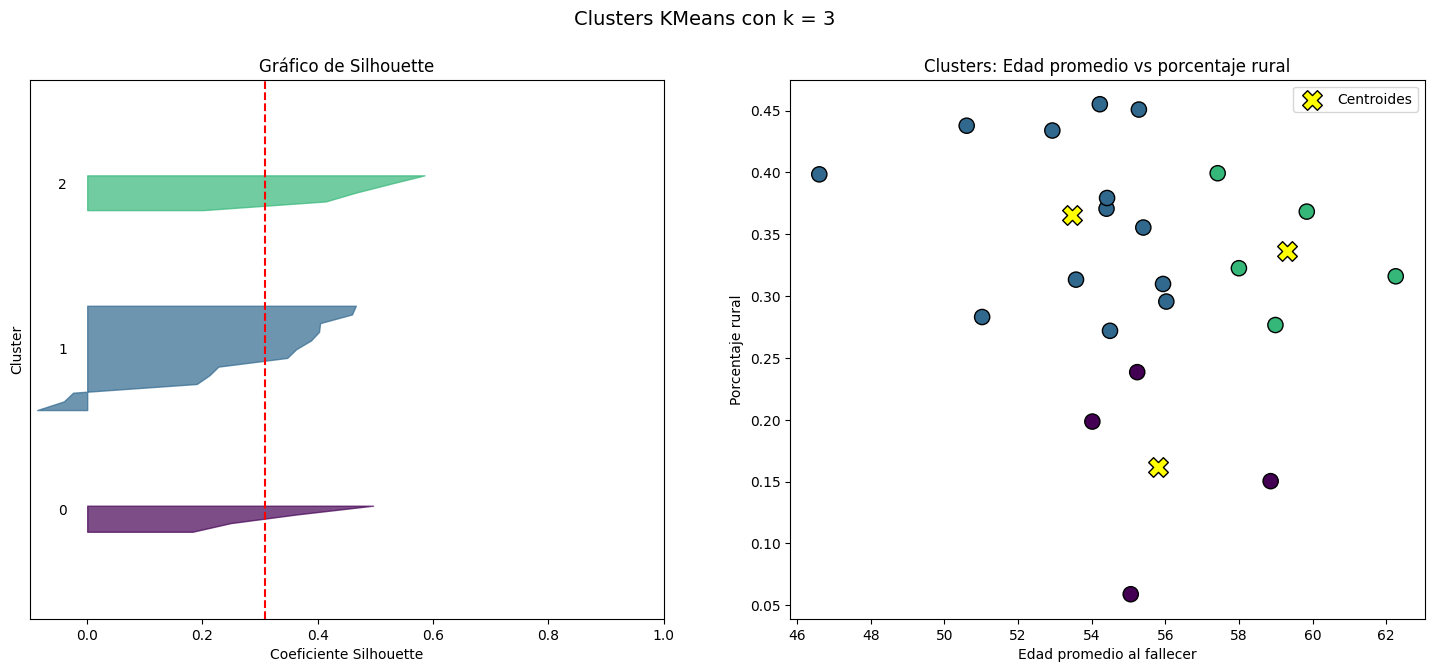

Para k = 4, silhouette = 0.319


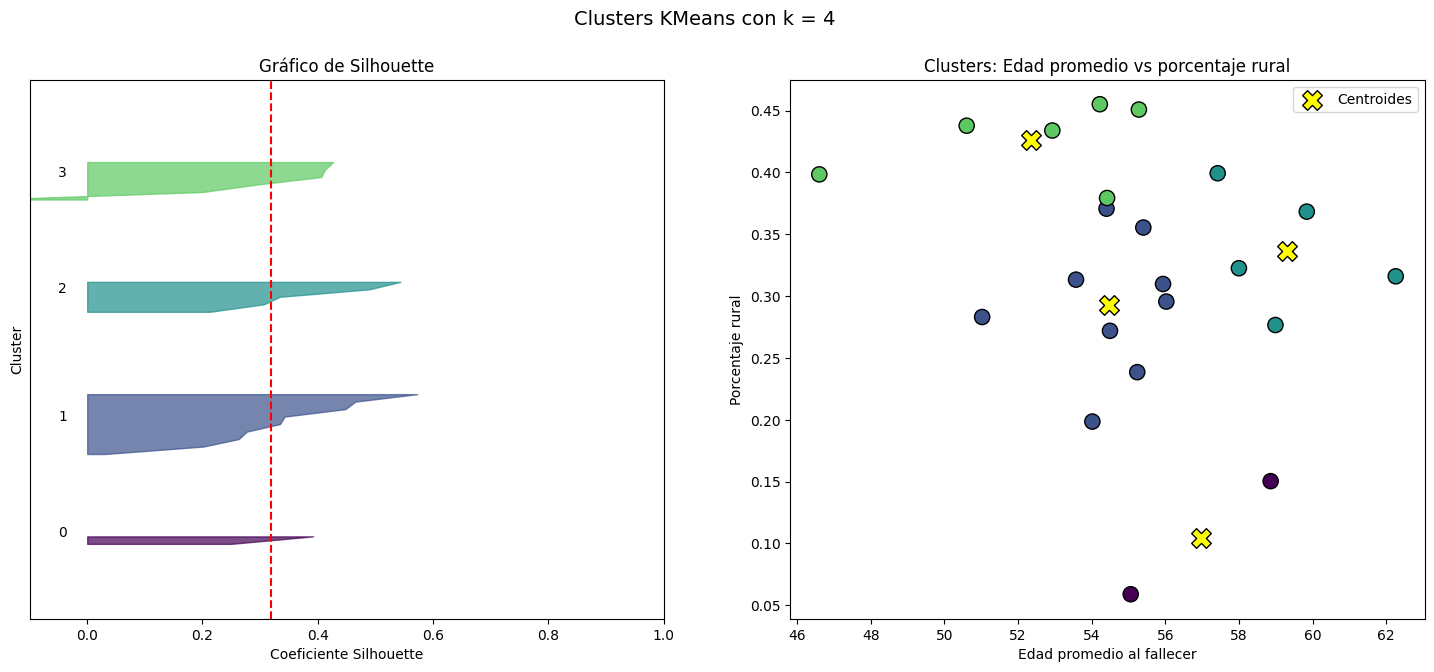

In [57]:
datosClustering = resumen_por_departamento[
    ["edad_promedio", "porcentaje_rural"]
]

escalar = StandardScaler() 
datosEscalados = escalar.fit_transform(datosClustering)

listaClusters = [2, 3, 4]

for numeroClusters in listaClusters:
    figura, (graficaSilhouette, graficaClusters) = plt.subplots(1, 2)
    figura.set_size_inches(18, 7)

    graficaSilhouette.set_xlim([ -0.1, 1] )
    graficaSilhouette.set_ylim([0 , len(datosEscalados)+ (numeroClusters + 1) * 10 ] )

    modeloKmeans = KMeans(n_clusters=numeroClusters, random_state=123 )
    etiquetasCluster = modeloKmeans.fit_predict(datosEscalados)

    promedioSilhouette = silhouette_score(datosEscalados, etiquetasCluster)
    print(f"Para k = {numeroClusters}, silhouette = {promedioSilhouette:.3f}")

    valoresSilhouette = silhouette_samples(datosEscalados, etiquetasCluster)

    limiteInferior = 10

    for clusterActual in range(numeroClusters ):

        valoresCluster= valoresSilhouette[etiquetasCluster  == clusterActual]
        valoresCluster.sort()

        tamañoCluster= valoresCluster.shape[0]
        limiteSuperior= limiteInferior +  tamañoCluster

        color= cm.viridis(float(clusterActual) /  numeroClusters)

        graficaSilhouette.fill_betweenx(
            np.arange(limiteInferior, limiteSuperior),
            0,
            valoresCluster,
            facecolor= color ,  
            edgecolor= color ,
            alpha=0.7,
        )

        graficaSilhouette.text(-0.05, limiteInferior + 0.5 * tamañoCluster, str(clusterActual))
        limiteInferior = limiteSuperior + 10

    graficaSilhouette.set_title("Gráfico de Silhouette")
    graficaSilhouette.set_xlabel("Coeficiente Silhouette")
    graficaSilhouette.set_ylabel("Cluster")
    graficaSilhouette.axvline(x=promedioSilhouette, color="red", linestyle="--")
    graficaSilhouette.set_yticks([])

    colores = cm.viridis(etiquetasCluster.astype(float) / numeroClusters)

    graficaClusters.scatter(
        datosClustering["edad_promedio"],
        datosClustering["porcentaje_rural"],
        c=colores,
        s= 120,
        edgecolor="black"
    )

    

    centroides = modeloKmeans.cluster_centers_
    centroidesOriginales = escalar.inverse_transform(centroides)

    graficaClusters.scatter(
        centroidesOriginales[:, 0],
        centroidesOriginales[: , 1],
        marker="X",
        c="yellow",
        s=200,
        edgecolor="black",
        label="Centroides"
    )

    graficaClusters.set_title("Clusters: Edad promedio vs porcentaje rural")
    graficaClusters.set_xlabel("Edad promedio al fallecer")
    graficaClusters.set_ylabel("Porcentaje rural")
    graficaClusters.legend()

    plt.suptitle(f"Clusters KMeans con k = {numeroClusters}", fontsize=14)
    plt.show()



## Datos adicionales para problema

#### edad por departamento

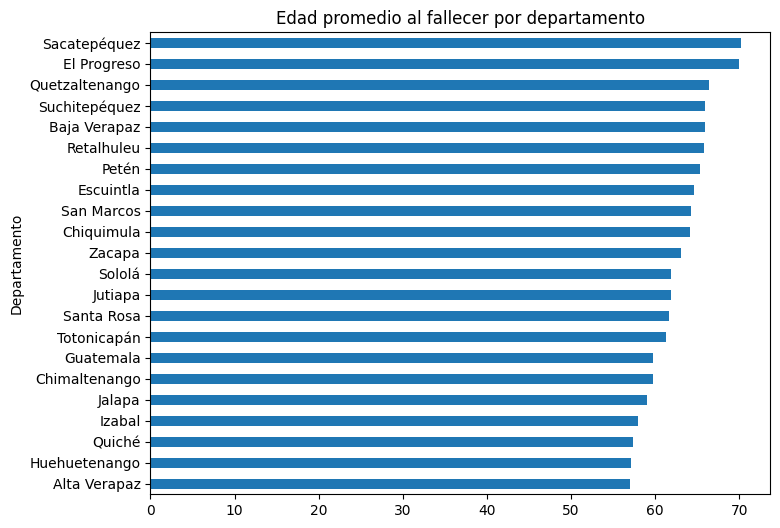

In [58]:
edadDepa = data_all.groupby("Departamento")["Edadif"].mean().sort_values()

plt.figure(figsize=(8,6))
edadDepa.plot(kind="barh")
plt.title("Edad promedio al fallecer por departamento")
plt.show()

#### heatmap

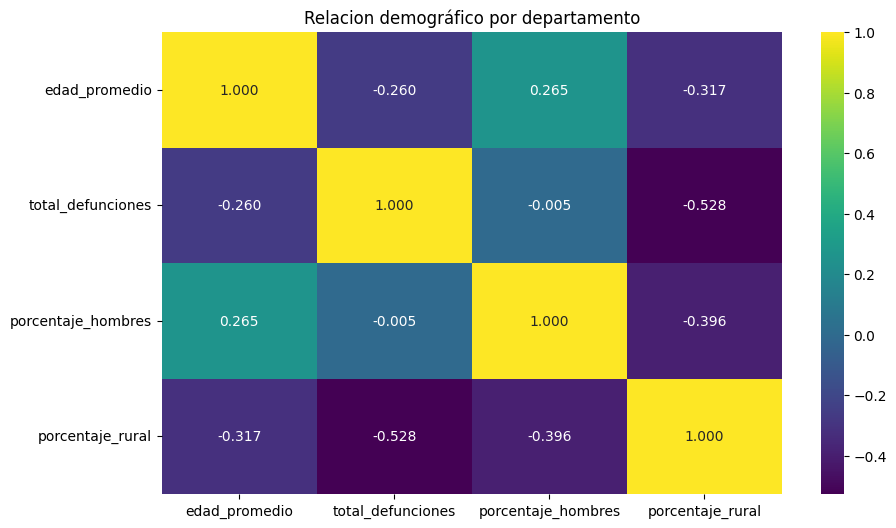

In [59]:
resumen_departamento = data_all.groupby("Departamento").agg(
    edad_promedio = ("Edadif", "mean") ,
    total_defunciones = ("Edadif", "count"),
    
    porcentaje_hombres = ("Sexo_desc" , lambda x: (x == "Hombre").mean() ) ,
    
    porcentaje_rural = ("Area_desc", lambda x: (x == "Rural").mean() )

).reset_index()


plt.figure(figsize=(10, 6 ) )

sns.heatmap(
    resumen_departamento.drop("Departamento", axis=1).corr(),
    annot=True,
    cmap="viridis",
    fmt=".3f"
)

plt.title("Relacion demográfico por departamento")
plt.show()


C:\Users\agabr\AppData\Local\Temp\ipykernel_5924\1844984947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


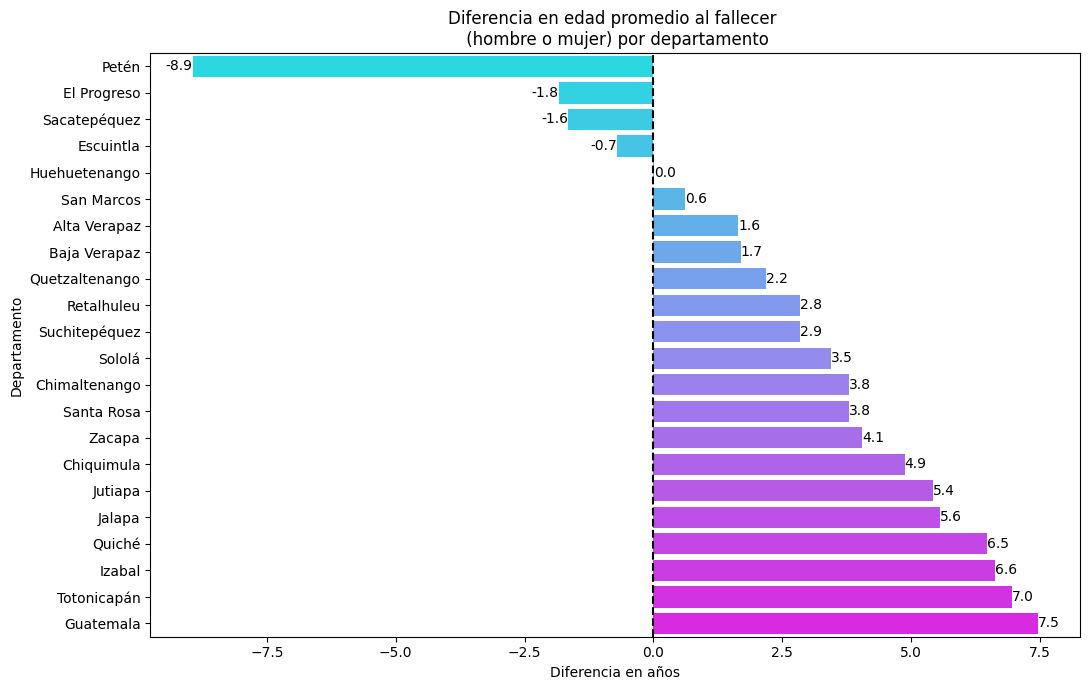

In [60]:
edad_sexo = data_all.groupby(["Departamento", "Sexo_desc"])["Edadif"].mean().unstack()

edad_sexo["diferencia_mujer_hombre"] = (
    edad_sexo["Mujer"] - edad_sexo["Hombre"]
)

edad_sexo = edad_sexo.sort_values("diferencia_mujer_hombre")

plt.figure(figsize=(11,7))
sns.barplot(
    y=edad_sexo.index,
    x=edad_sexo["diferencia_mujer_hombre"],
    palette="cool",
)

plt.axvline(0, color="black", linestyle="--")

for i, valor in enumerate(edad_sexo["diferencia_mujer_hombre"]):
    plt.text(
        valor,
        i,
        f"{valor:.1f}",
        va="center",
        ha="left" if valor > 0 else "right"
    )

plt.title("Diferencia en edad promedio al fallecer \n (hombre o mujer) por departamento")
plt.xlabel("Diferencia en años")
plt.ylabel("Departamento")

plt.tight_layout()
plt.show()

#### Frecuencia 

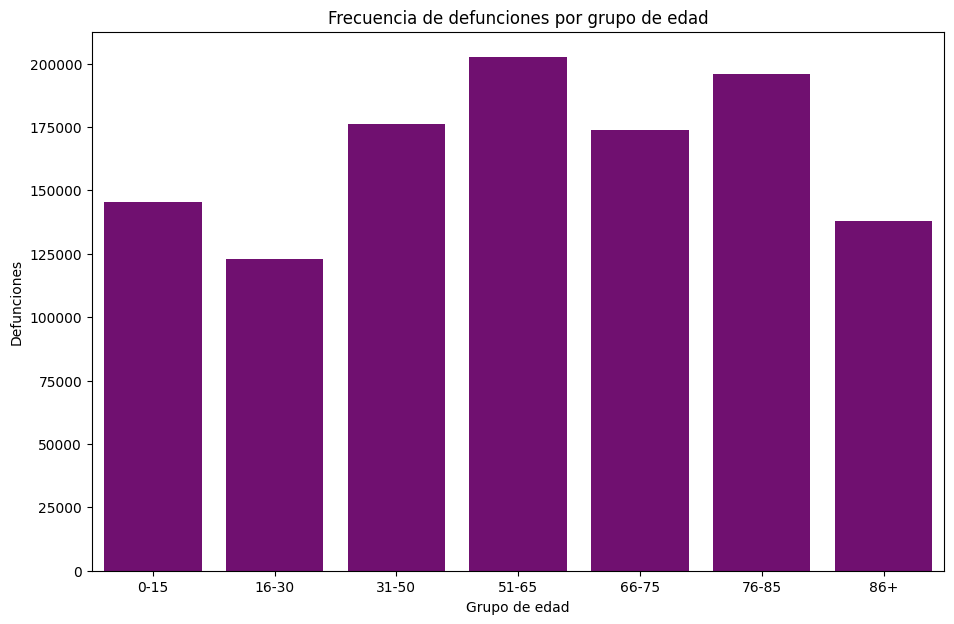

In [61]:
data_all["grupoEdad"] = pd.cut(
    data_all["Edadif"],
    bins=[0, 15, 30, 50, 65, 75, 85, 110],
    labels=[ "0-15" ,"16-30" ,"31-50","51-65","66-75", "76-85", "86+" ]
)

frecuenciaEdad = data_all["grupoEdad"].value_counts().sort_index()

plt.figure(figsize=(11, 7))
sns.barplot(
    x=frecuenciaEdad.index,
    y=frecuenciaEdad.values,
    color="purple"
)

plt.title("Frecuencia de defunciones por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Defunciones")
plt.show()



C:\Users\agabr\AppData\Local\Temp\ipykernel_5924\3652986005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


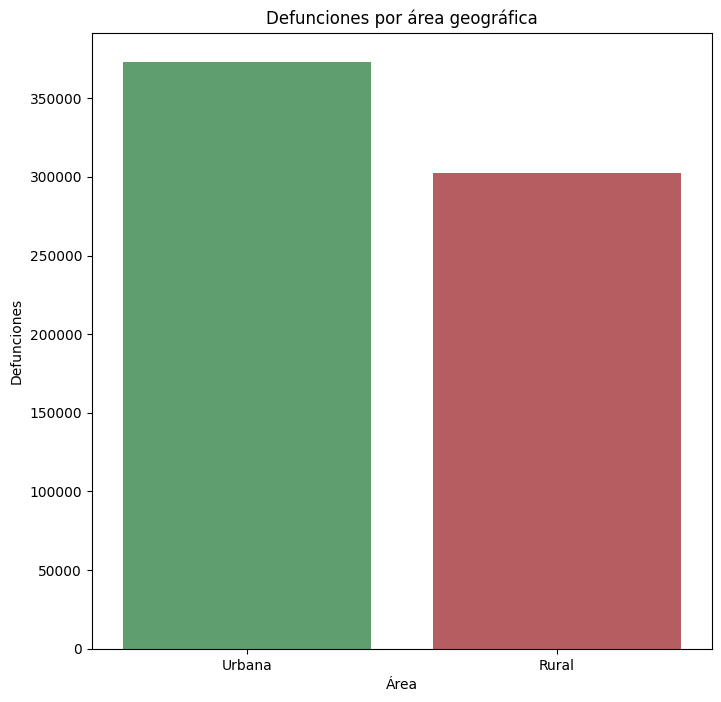

In [62]:
frecuenciaArea = data_all["Area_desc" ].value_counts()

plt.figure(figsize=(8,8 )) 

sns.barplot(
    x=frecuenciaArea.index,
    y=frecuenciaArea.values,
    palette=["#55A868","#C44E52"]
)

plt.title("Defunciones por área geográfica")
plt.xlabel("Área")
plt.ylabel("Defunciones")
plt.show()


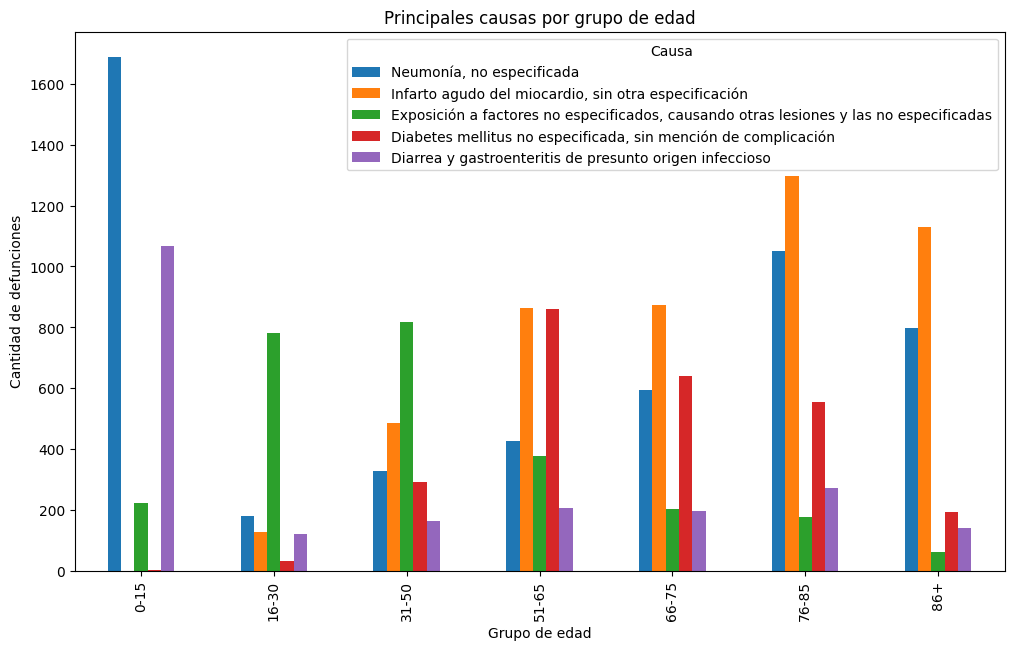

In [63]:
tablaEdadCausa = pd.crosstab(
    data_all["grupoEdad"] ,
    data_all["caudef.descrip" ] )

top5Causas = data_all["caudef.descrip"].value_counts().head(5).index

tablaFiltrada = tablaEdadCausa[top5Causas]

tablaFiltrada.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Principales causas por grupo de edad" )
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de defunciones" )
plt.legend(title="Causa")
plt.show()


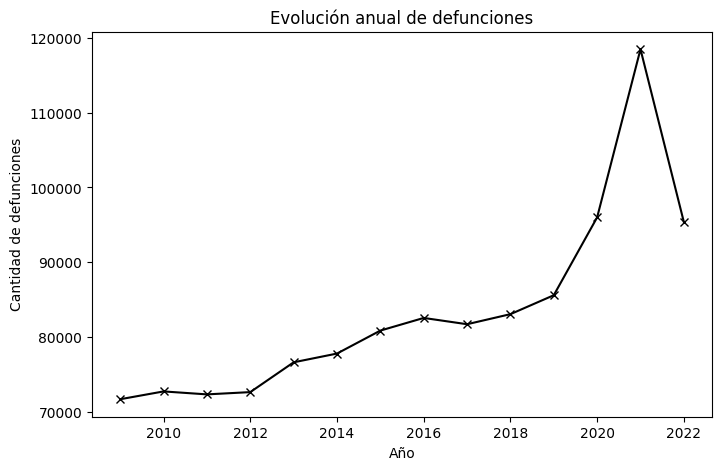

In [64]:
defuncionesPorAnio = data_all.groupby("anio" ).size()

plt.figure(figsize=(8,5))
plt.plot(
    defuncionesPorAnio.index,
    defuncionesPorAnio.values,
    marker="x",
    color="black"
)

plt.title("Evolución anual de defunciones" )
plt.xlabel("Año" )
plt.ylabel("Cantidad de defunciones" )
plt.show( )



#### histogramas

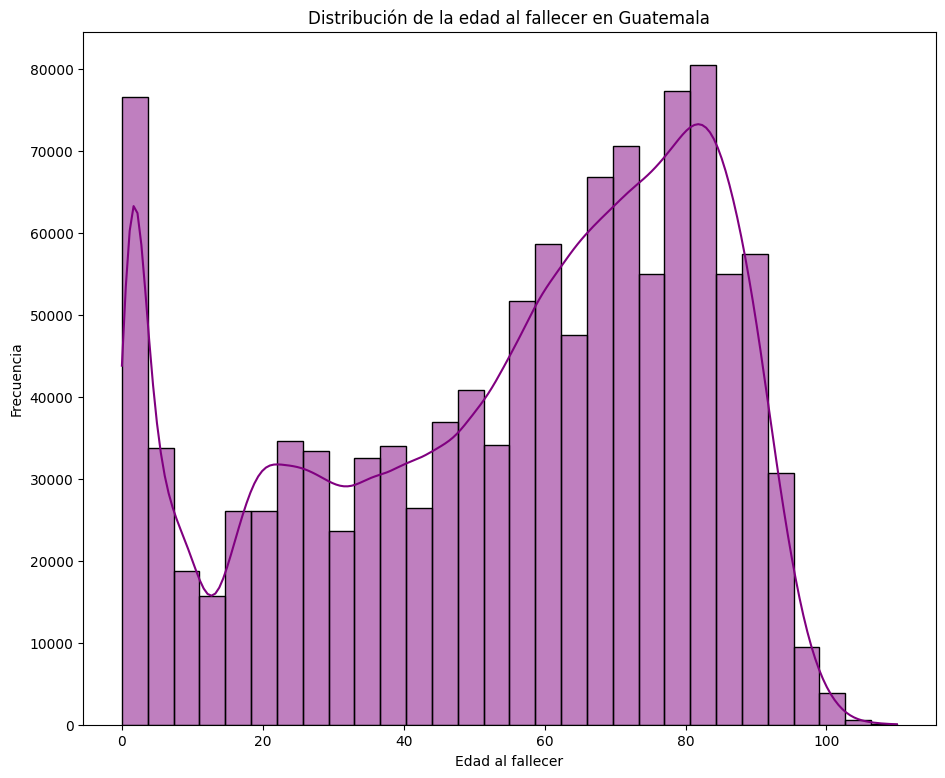

In [65]:

datosEdad = data_all[
    (data_all["Edadif"] >= 0) &
    (data_all["Edadif"] <= 110) ].copy()

plt.figure(figsize=(11, 9))

sns.histplot(
    data=datosEdad,
    x="Edadif" ,
    
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribución de la edad al fallecer en Guatemala")
plt.xlabel("Edad al fallecer")
plt.ylabel("Frecuencia")
plt.show()


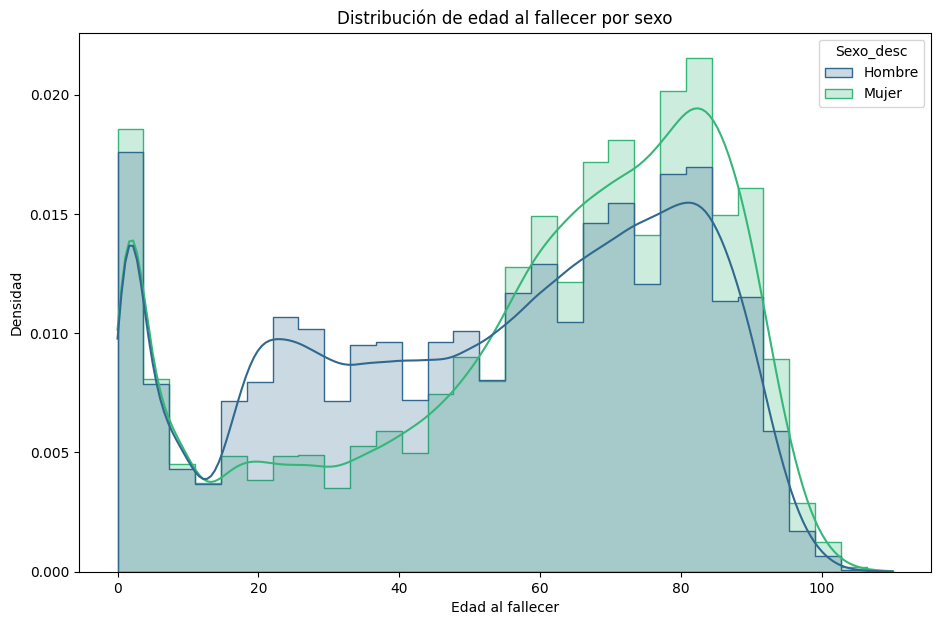

In [66]:
plt.figure(figsize=(11, 7))

sns.histplot(
    data=datosEdad,
    x="Edadif",
    hue="Sexo_desc" ,
    bins=30,
    kde=True,
    element="step" ,
    stat="density" ,
    common_norm=False,
    palette="viridis"
)

plt.title("Distribución de edad al fallecer por sexo")
plt.xlabel("Edad al fallecer")
plt.ylabel("Densidad")
plt.show()


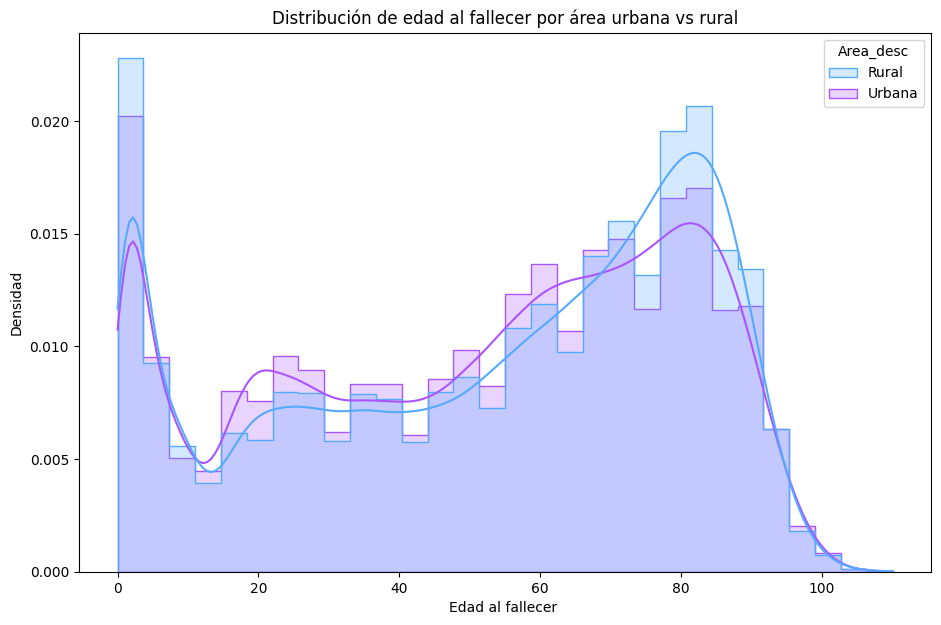

In [67]:
plt.figure(figsize=(11, 7))

sns.histplot(
    data=datosEdad,
    x="Edadif",
    hue="Area_desc",
    bins=30,
    kde=True,
    element="step" ,
    stat="density",
    common_norm=False ,
    palette="cool",
)

plt.title("Distribución de edad al fallecer por área urbana vs rural")
plt.xlabel("Edad al fallecer " )
plt.ylabel("Densidad")
plt.show()


# parte #2 del proyecto

In [68]:
#La variable respuesta seleccionada para el proyecto es el tipo de causa de defunción. 
# Esta variable es de tipo categórica, ya que clasifica cada registro en diferentes grupos de causas, 
# tales como infecciosas, crónicas, cardiovasculares y externas.

#La elección de esta variable se fundamenta en que permite simplificar la gran cantidad de causas 
# individuales registradas en los datos, facilitando así el análisis e interpretación de los patrones
# de mortalidad. Además, esta variable permite estudiar la relación entre las características demográficas 
# y territoriales (como edad, sexo y área geográfica) y el tipo de causa de defunción, lo cual está 
# alineado con el problema planteado en el proyecto.

#### crear variables X y Y

In [83]:
# Eliminar valores nulos
data_model = data_all.dropna(subset=["Edadif", "Sexo_desc", "Area_desc", "tipo_causa"])

data_model = data_model[(data_model["Edadif"] >= 0) & (data_model["Edadif"] < 120)]

data_model = data_model[data_model["tipo_causa"] != "Otras"]


In [84]:
# Preparación de datos para modelos (X y Y)
# Selección de variables explicativas
variables = ["Edadif", "Sexo_desc", "Area_desc"]
X = data_model[variables]
y = data_model["tipo_causa"]

In [85]:
# Verificación de datos
print(X.head())
print("\n")
print(y.head())

        Edadif Sexo_desc Area_desc
289486    13.0     Mujer    Urbana
289487    50.0    Hombre     Rural
289488     3.0    Hombre    Urbana
289512    95.0    Hombre    Urbana
289513    55.0    Hombre    Urbana


289486    Infecciosas
289487    Infecciosas
289488    Infecciosas
289512    Infecciosas
289513    Infecciosas
Name: tipo_causa, dtype: str


In [86]:
# Codificación de variables categóricas

X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

In [87]:
# Verificación final de X
print(X.head())
print(X.shape)

        Edadif  Sexo_desc_Mujer  Area_desc_Urbana
289486      13                1                 1
289487      50                0                 0
289488       3                0                 1
289512      95                0                 1
289513      55                0                 1
(32616, 3)


#### train test

In [88]:
# División en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [89]:
# Verificación de tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26092, 3)
X_test: (6524, 3)
y_train: (26092,)
y_test: (6524,)


In [90]:
# Modelo 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_lr = accuracy_score(y_test, y_pred_lr)
matriz_lr = confusion_matrix(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)
print("Matriz de confusión:\n", matriz_lr)

Accuracy: 0.4906499080318823
Matriz de confusión:
 [[  29  864    0  298]
 [  21 1799    0  628]
 [   7  317    0  250]
 [  42  896    0 1373]]


In [92]:
# Modelo 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)
matriz_rf = confusion_matrix(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy_rf)
print("Matriz de confusión:\n", matriz_rf)

Accuracy Random Forest: 0.5458307786633967
Matriz de confusión:
 [[ 103  714    6  368]
 [  86 1963   18  381]
 [  31  300   36  207]
 [  74  748   30 1459]]


In [94]:
# Modelo 3: K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)

modelo_knn.fit(X_train, y_train)

y_pred_knn = modelo_knn.predict(X_test)

In [95]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
matriz_knn = confusion_matrix(y_test, y_pred_knn)

print("Accuracy KNN:", accuracy_knn)
print("Matriz de confusión:\n", matriz_knn)

Accuracy KNN: 0.4920294297976701
Matriz de confusión:
 [[ 333  580   31  247]
 [ 530 1563   53  302]
 [ 117  254   57  146]
 [ 318  660   76 1257]]


In [96]:
print("Logistic Regression:", accuracy_lr)
print("Random Forest:", accuracy_rf)
print("KNN:", accuracy_knn)

Logistic Regression: 0.4906499080318823
Random Forest: 0.5458307786633967
KNN: 0.4920294297976701
